In [34]:
import osmnx as ox
import pandas as pd
import networkx as nx
import geopandas as gpd

## Import graph

In [ ]:
G = gpd.read_file("../../layers/barcelona.graphml")

EPSG:25831
(15115, 30)
['TRAM', 'TOTAL_D', 'TOTAL_E', 'TOTAL_N', 'TOTAL_DEN', 'TRANSIT_D', 'TRANSIT_E', 'TRANSIT_N', 'TRANSIT_DEN', 'GI_TR_D', 'GI_TR_E', 'GI_TR_N', 'GI_TR_DEN', 'FFCC_D', 'FFCC_E', 'FFCC_N', 'FFCC_DEN', 'INDUST_D', 'INDUST_E', 'INDUST_N', 'INDUST_DEN', 'VIANANTS_D', 'VIANANTS_E', 'OCI_N', 'PATIS_D', 'PATIS_E', 'geometry_type', 'start', 'end', 'geometry']
Number of street segments: 15115


## Compute centrality

IMPORTANT! It takes long to run

Betwenness centrality based on edges is the strongest predictor of noise, as it is related to traffic flow.

In [ ]:
G = ox.distance.add_edge_lengths(G)

In [37]:
ebc = nx.edge_betweenness_centrality(G, weight='length', normalized=True)
nx.set_edge_attributes(G, ebc, 'edge_betweenness')

nodes, edges = ox.graph_to_gdfs(G)

## Spatial join with noise streets

Text(0.5, 1.0, 'Edge Betweenness')

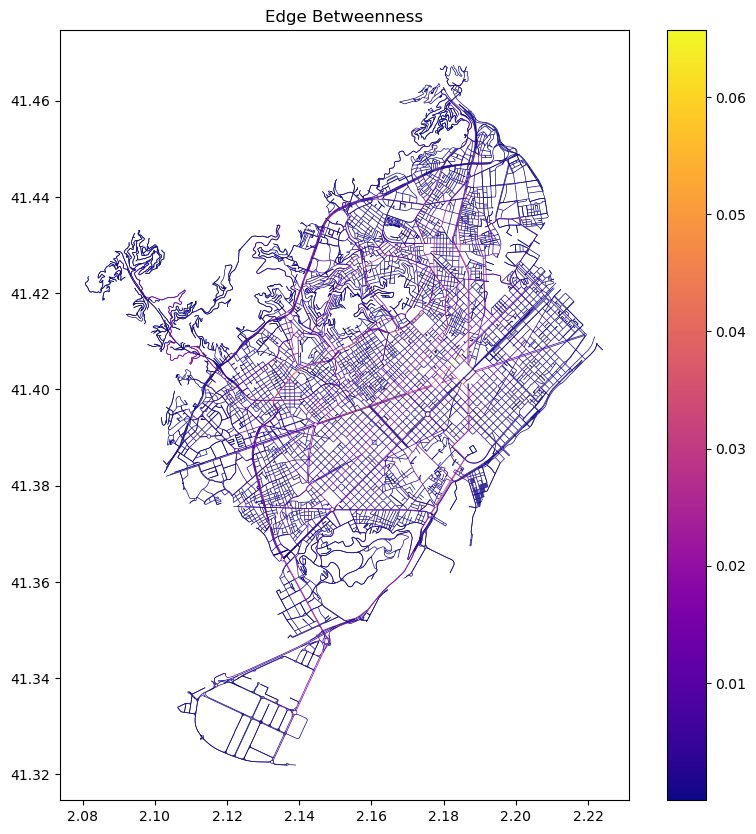

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(cmap='plasma', column='edge_betweenness', linewidth=0.5, legend=True, ax=ax)
ax.set_title('Edge Betweenness')

## Create dataset

In [48]:
edges["segment_id"] = edges.index.map(lambda x: f"{x[0]}_{x[1]}_{x[2]}")
dataset = pd.DataFrame({
    "road_id": edges['segment_id'],
})
dataset['edge_betweenness'] = edges['edge_betweenness']

## Export as CSV

In [49]:
import os
import matplotlib.pyplot as plt
output_dir = "../../data/processed"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "networkx_streets.csv"), index=False)
print("Exported networkx_streets.csv")
dataset.head()



Exported networkx_streets.csv


road_id  edge_betweenness
u        v           key                                          
21638845 885308258   0      21638845_885308258_0          0.000880
         13175411896 0    21638845_13175411896_0          0.000989
21638865 30343650    0       21638865_30343650_0          0.000110
21638867 1636238503  0     21638867_1636238503_0          0.000319
         1403082237  0     21638867_1403082237_0          0.001709

In [ ]:
"""
noise_streets['centroid'] = noise_streets.geometry.centroid

cc = nx.closeness_centrality(G, distance='length')
nx.set_node_attributes(G, cc, 'closeness')

bc = nx.betweenness_centrality(G, weight='length', normalized=True)
nx.set_node_attributes(G, bc, 'betweenness')

noise_streets = noise_streets.sjoin_nearest(
    nodes[['closeness', 'geometry']],
    how='left',
    distance_col='dist_to_node'
)

noise_streets = noise_streets.sjoin_nearest(
    nodes[['betweenness', 'geometry']],
    how='left'
)


TODO: add straightness
"""

"\nnoise_streets['centroid'] = noise_streets.geometry.centroid\n\ncc = nx.closeness_centrality(G, distance='length')\nnx.set_node_attributes(G, cc, 'closeness')\n\nbc = nx.betweenness_centrality(G, weight='length', normalized=True)\nnx.set_node_attributes(G, bc, 'betweenness')\n\nnoise_streets = noise_streets.sjoin_nearest(\n    nodes[['closeness', 'geometry']],\n    how='left',\n    distance_col='dist_to_node'\n)\n\nnoise_streets = noise_streets.sjoin_nearest(\n    nodes[['betweenness', 'geometry']],\n    how='left'\n)\n\n\nTODO: add straightness\n"